In [1]:
pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load CSV
boston = pd.read_csv('boston.csv')

# Features (all except MEDV)
X = boston.drop('MEDV', axis=1)

# Target
y = boston['MEDV']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

/home/admin1/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-04 14:26:06.556935: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [17]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [18]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 610.6168 - mae: 22.7960 - val_loss: 534.4623 - val_mae: 21.5554
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 611.5667 - mae: 22.9578 - val_loss: 505.2407 - val_mae: 20.8478
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 542.0704 - mae: 21.1414 - val_loss: 471.9964 - val_mae: 20.0257
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 514.3372 - mae: 20.3168 - val_loss: 430.7834 - val_mae: 18.9881
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 491.5176 - mae: 19.8782 - val_loss: 380.6968 - val_mae: 17.6692
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 403.1032 - mae: 17.7614 - val_loss: 322.4109 - val_mae: 16.0199
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 336.2688 - mae: 16.3115 - val_loss: 256.9312 - val_mae: 14.0637
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 247.2881 - mae: 13.4923 - val_loss: 195.0461 - val_mae: 11.9048
Epoch 9/10
11/11

In [19]:
loss, mae = model.evaluate(X_test,y_test)
print(loss, mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 72.0598 - mae: 7.0775
78.3567886352539 7.140576362609863


In [20]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


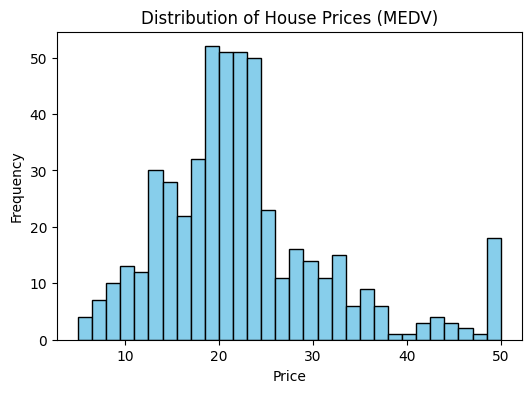

In [21]:
# Cell 10: Histogram of target variable (House prices)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

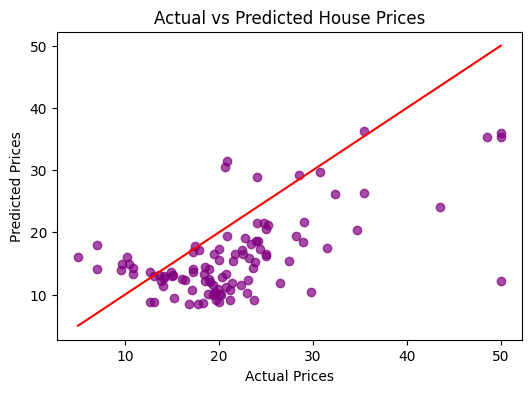

In [22]:
# Cell 11: Scatter plot (Actual vs Predicted)
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # ideal line
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()